Memuat data dan objek pendukung...
Data Testing siap: 434 sampel

Memuat Model CNN...
Melakukan inferensi pada data testing...


2026-05-08 22:22:12.428607: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


14/14 [==============================] - 1s 10ms/step


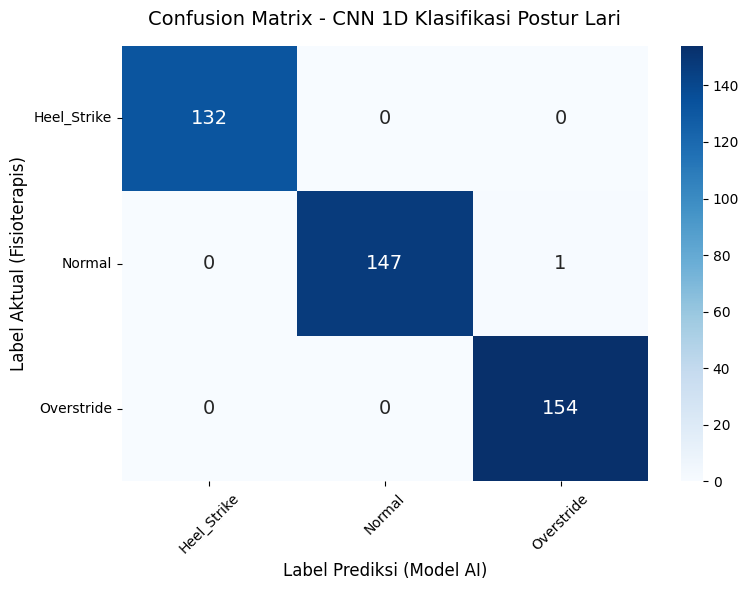


LAPORAN KLASIFIKASI (METRIK EVALUASI)
              precision    recall  f1-score   support

 Heel_Strike       1.00      1.00      1.00       132
      Normal       1.00      0.99      1.00       148
  Overstride       0.99      1.00      1.00       154

    accuracy                           1.00       434
   macro avg       1.00      1.00      1.00       434
weighted avg       1.00      1.00      1.00       434



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import joblib

# =========================================================
# 1. REKONSTRUKSI DATA TESTING (Identik dengan Notebook 02)
# =========================================================
print("Memuat data dan objek pendukung...")
DATA_PATH = '../data/results/running_dataset.csv'
df = pd.read_csv(DATA_PATH)

# Proses undersampling yang sama persis
MAX_SAMPLES = 722
df_normal = df[df['label'] == 'Normal'].sample(n=min(MAX_SAMPLES, len(df[df['label'] == 'Normal'])), random_state=42)
df_heel = df[df['label'] == 'Heel_Strike'].sample(n=min(MAX_SAMPLES, len(df[df['label'] == 'Heel_Strike'])), random_state=42)
df_overstride = df[df['label'] == 'Overstride'].sample(n=min(MAX_SAMPLES, len(df[df['label'] == 'Overstride'])), random_state=42)

df_balanced = pd.concat([df_normal, df_heel, df_overstride]).sample(frac=1, random_state=42).reset_index(drop=True)

# Pisahkan fitur
X = df_balanced.drop(['label', 'source_video'], axis=1, errors='ignore').values
y = df_balanced['label'].values

# Load Encoder dan Scaler yang sudah di-fit pada Notebook 02
encoder = joblib.load('../models/label_encoder.pkl')
scaler = joblib.load('../models/scaler.pkl')

y_encoded = encoder.transform(y)
X_scaled = scaler.transform(X)

# Split data dan ambil hanya X_test serta y_test
_, X_test, _, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Reshape untuk input CNN
X_test_cnn = np.expand_dims(X_test, axis=2)
print(f"Data Testing siap: {len(X_test_cnn)} sampel")

# =========================================================
# 2. LOAD MODEL TERBAIK & PREDIKSI
# =========================================================
print("\nMemuat Model CNN...")
model = tf.keras.models.load_model('../models/runform_model.h5')

print("Melakukan inferensi pada data testing...")
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# =========================================================
# 3. EVALUASI: CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
# Menggunakan heatmap dari seaborn untuk visualisasi matriks yang elegan
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_,
            annot_kws={"size": 14}) # Memperbesar angka di dalam kotak

plt.title('Confusion Matrix - CNN 1D Klasifikasi Postur Lari', fontsize=14, pad=15)
plt.ylabel('Label Aktual (Fisioterapis)', fontsize=12)
plt.xlabel('Label Prediksi (Model AI)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Simpan gambar untuk dilampirkan ke dokumen Tesis
plt.savefig('../data/results/confusion_matrix.png', dpi=300)
plt.show()

# =========================================================
# 4. EVALUASI: CLASSIFICATION REPORT (Precision, Recall, F1)
# =========================================================
print("\n" + "="*50)
print("LAPORAN KLASIFIKASI (METRIK EVALUASI)")
print("="*50)
print(classification_report(y_test, y_pred, target_names=encoder.classes_))